In [ ]:
import pandas as pd
import numpy as np

# Set a random seed for reproducibility
np.random.seed(42)

# Number of records
num_records = 250 # Modified value

# Generate Employee_ID
employee_ids = [f'EMP{i+1:03d}' for i in range(num_records)]

# Generate Department
departments = np.random.choice(['HR', 'Engineering', 'Sales', 'Marketing', 'Finance'], size=num_records, p=[0.1, 0.3, 0.2, 0.2, 0.2])

# Generate Job_Level (1 to 5)
job_levels = np.random.randint(1, 6, size=num_records)

# Generate Age
ages = np.random.randint(22, 60, size=num_records)

# Generate Years_of_Experience (correlated with Age)
years_of_experience = np.random.randint(0, ages - 20).clip(min=0)

# Generate Monthly_Salary (correlated with Job_Level and Years_of_Experience)
monthly_salary = (6000 + job_levels * 1000 + years_of_experience * 250 + np.random.normal(0, 1700, num_records)).round(2) # Modified values
monthly_salary = monthly_salary.clip(min=3000)

# Generate Satisfaction_Score (1 to 10)
satisfaction_scores = np.random.randint(1, 11, size=num_records)

# Generate Working_Hours_per_Week
working_hours = np.random.randint(35, 50, size=num_records)

# Create DataFrame
df = pd.DataFrame({
    'Employee_ID': employee_ids,
    'Department': departments,
    'Job_Level': job_levels,
    'Age': ages,
    'Years_of_Experience': years_of_experience,
    'Monthly_Salary': monthly_salary,
    'Satisfaction_Score': satisfaction_scores,
    'Working_Hours_per_Week': working_hours
})

# Display the first few rows of the dataset
display(df.head())

# Save to CSV
df.to_csv('employee_data.csv', index=False)
print('\nSynthetic dataset "employee_data.csv" created successfully with 250 records.')

,Employee_ID,Department,Job_Level,Age,Years_of_Experience,Monthly_Salary,Satisfaction_Score,Working_Hours_per_Week
0,EMP001,Engineering,5,22,0,9279.42,2,44
1,EMP002,Finance,5,43,7,9936.74,8,37
2,EMP003,Marketing,1,38,7,10149.39,1,37
3,EMP004,Sales,3,28,0,9124.64,6,44
4,EMP005,Engineering,2,46,11,8557.07,8,40



Synthetic dataset "employee_data.csv" created successfully with 250 records.


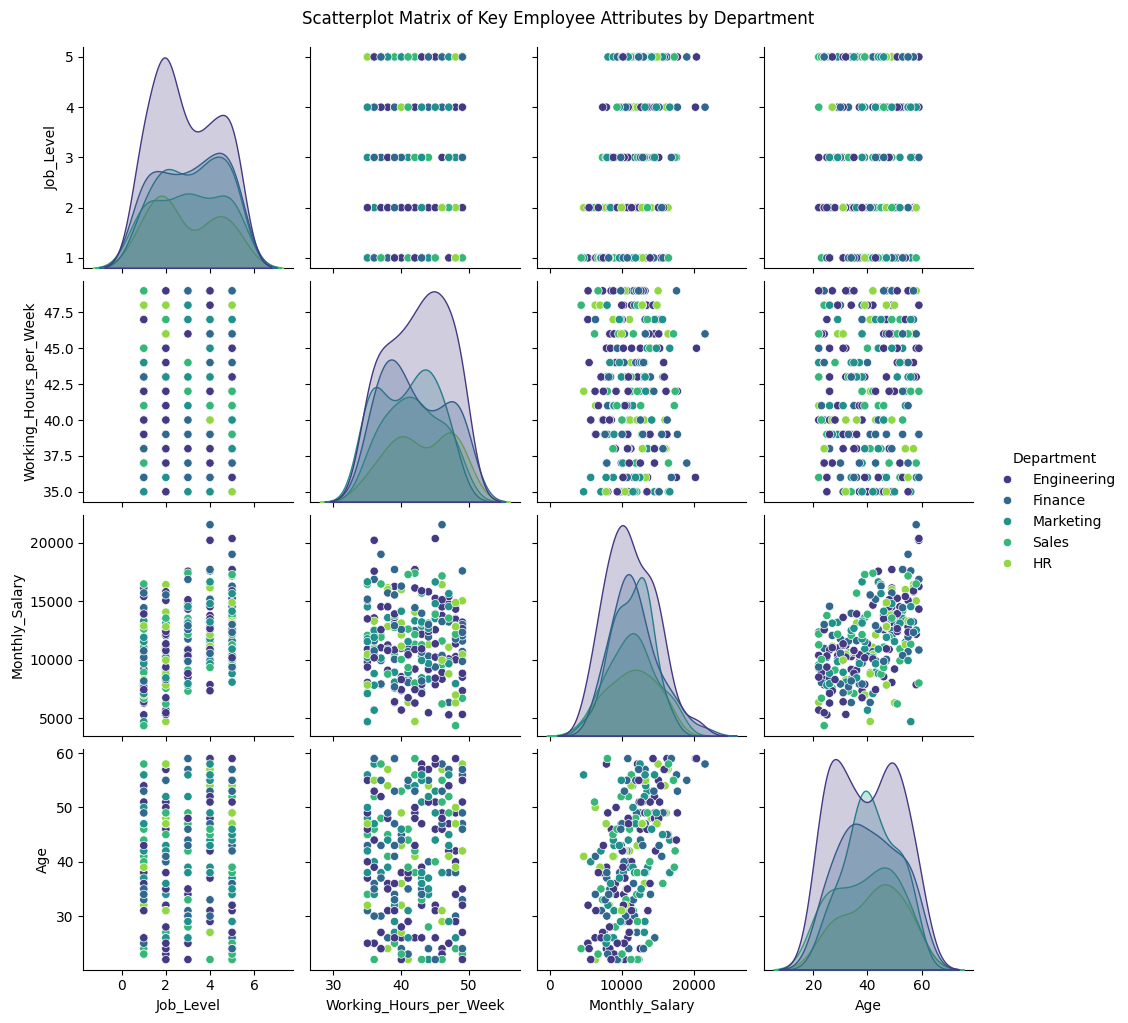

In [ ]:
import seaborn as sns
import matplotlib.pyplot as plt

# Select the numerical columns for the scatterplot matrix
columns_for_pairplot = ['Job_Level', 'Working_Hours_per_Week', 'Monthly_Salary', 'Age']

# Create the scatterplot matrix with hue='Department'
sns.pairplot(df, vars=columns_for_pairplot, hue='Department', palette='viridis', height=2.5)
plt.suptitle('Scatterplot Matrix of Key Employee Attributes by Department', y=1.02) # Adjust suptitle position
plt.show()

In [ ]:
import plotly.express as px
import numpy as np

# Create a numerical representation of the 'Department' column
# This converts the categorical strings to unique integers (0, 1, 2, ...)
df['Department_Code'] = df['Department'].astype('category').cat.codes

# Create the Parallel Coordinates Plot with modified dimensions
fig = px.parallel_coordinates(df,
                              dimensions=['Job_Level', 'Years_of_Experience', 'Monthly_Salary', 'Satisfaction_Score'],
                              color='Department_Code',
                              color_continuous_scale=px.colors.sequential.Viridis,
                              title='Parallel Coordinates Plot of Employee Attributes by Department (Modified)')

fig.show()

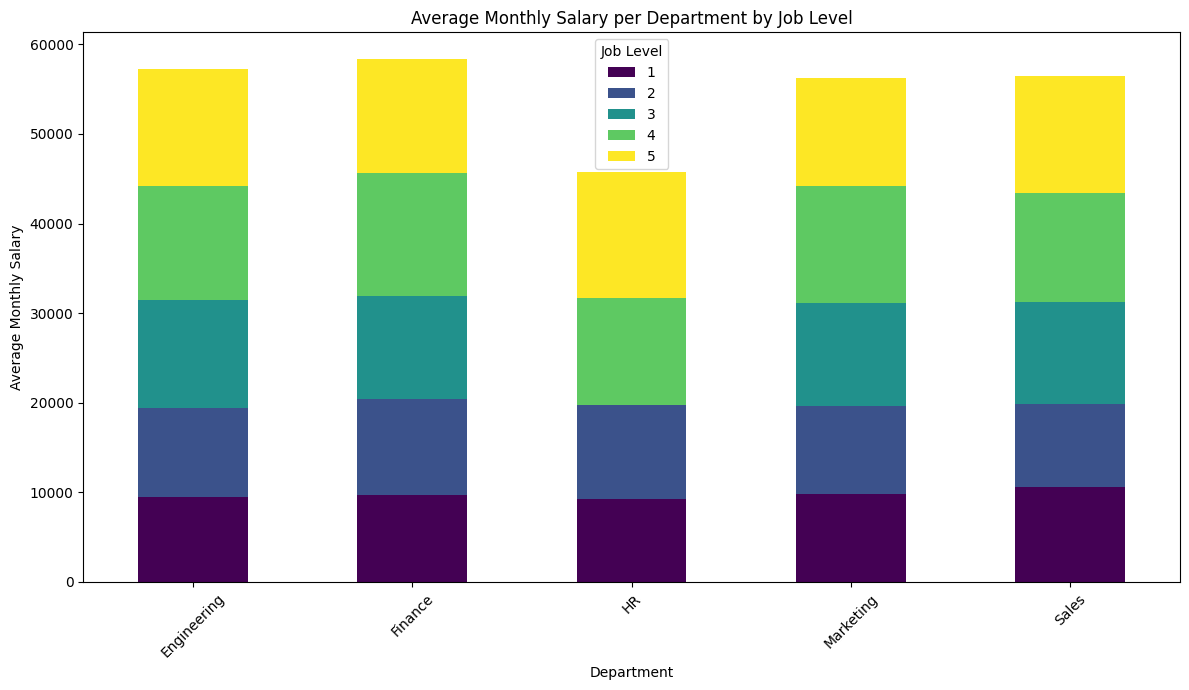

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

# Calculate the average Monthly_Salary per Department and Job_Level
department_job_level_salary = df.groupby(['Department', 'Job_Level'])['Monthly_Salary'].mean().unstack(fill_value=0)

# Plotting the stacked bar chart
department_job_level_salary.plot(kind='bar', stacked=True, figsize=(12, 7), colormap='viridis')

plt.title('Average Monthly Salary per Department by Job Level')
plt.xlabel('Department')
plt.ylabel('Average Monthly Salary')
plt.xticks(rotation=45)
plt.legend(title='Job Level')
plt.tight_layout() # Adjust layout to prevent labels from overlapping
plt.show()

In [ ]:
import pandas as pd

df = pd.read_csv('employee_data.csv')

print('Dataset loaded successfully.')
display(df.head())
print('\nDataset Info:')
df.info()

Dataset loaded successfully.


,Employee_ID,Department,Job_Level,Age,Years_of_Experience,Monthly_Salary,Satisfaction_Score,Working_Hours_per_Week
0,EMP001,Engineering,5,22,0,9279.42,2,44
1,EMP002,Finance,5,43,7,9936.74,8,37
2,EMP003,Marketing,1,38,7,10149.39,1,37
3,EMP004,Sales,3,28,0,9124.64,6,44
4,EMP005,Engineering,2,46,11,8557.07,8,40



Dataset Info:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 250 entries, 0 to 249
Data columns (total 8 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Employee_ID             250 non-null    object 
 1   Department              250 non-null    object 
 2   Job_Level               250 non-null    int64  
 3   Age                     250 non-null    int64  
 4   Years_of_Experience     250 non-null    int64  
 5   Monthly_Salary          250 non-null    float64
 6   Satisfaction_Score      250 non-null    int64  
 7   Working_Hours_per_Week  250 non-null    int64  
dtypes: float64(1), int64(5), object(2)
memory usage: 15.8+ KB
